# 03 · Trends & Demand Forecasting

**Business question:** How seasonal is demand, which categories and colours are gaining
or losing share, and how well can simple methods forecast next quarter's demand?

**Y1** and **Y2** are back-to-back 52-week years ending on the last complete week of
data. Y2 includes spring 2020, when COVID-19 restrictions closed stores. Store sales
collapsed while online sales grew, so total demand fell far less than store sales did,
and the year-over-year comparisons partly reflect that channel shift. Seasonality is
measured on Y1 only.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from hm_analytics import HM, charts, forecast

charts.apply_style()
pd.options.display.float_format = "{:,.3f}".format
hm = HM()

COVID_START, COVID_END = "2020-03-16", "2020-05-31"   # store closures and reopening, shaded on charts


def shade_covid(ax):
    ax.axvspan(pd.Timestamp(COVID_START), pd.Timestamp(COVID_END), color=charts.GRID, zorder=0)
    ax.text(pd.Timestamp(COVID_START), 1.0, " COVID-19: stores\n closed, sales\n moved online",
            transform=ax.get_xaxis_transform(), va="top", fontsize=8.5, color=charts.TEXT_SECONDARY)

## 1. Weekly demand and the shift online

During the COVID-19 window stores were closed for about six weeks and then reopened.
Store units fell to almost zero while online units rose, so the drop in total units is
much smaller than the drop in store units.

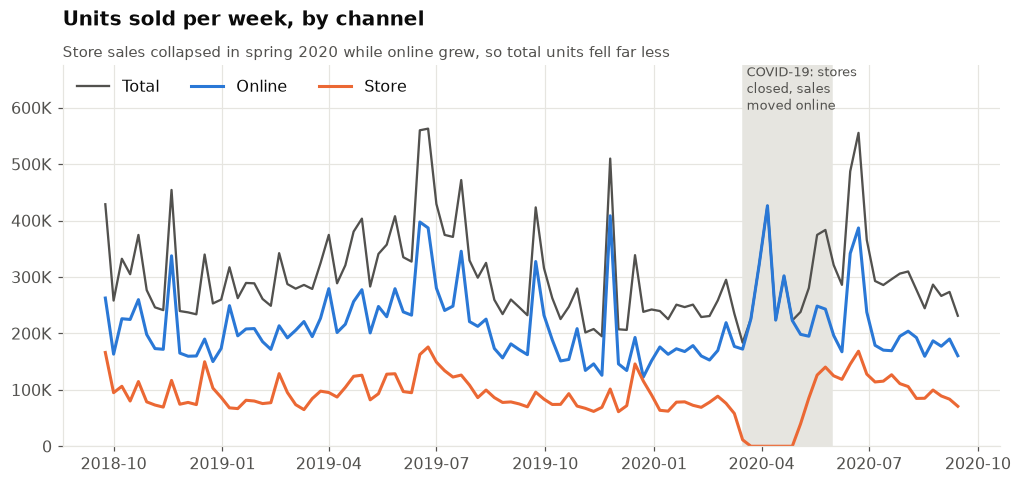

In [2]:
online = hm.q("weekly_online_share")
online["online_units"] = online.units * online.online_unit_share
online["store_units"] = online.units - online.online_units

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(online.week_start, online.units, color=charts.TEXT_SECONDARY, linewidth=1.5, label="Total")
ax.plot(online.week_start, online.online_units, color=charts.ACCENT, label="Online")
ax.plot(online.week_start, online.store_units, color=charts.SERIES[1], label="Store")
shade_covid(ax)
ax.set_ylim(0, online.units.max() * 1.2)   # headroom for the legend
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v / 1e3:,.0f}K" if v else "0"))
ax.legend(loc="upper left", ncols=3)
ax.set_title("Units sold per week, by channel")
charts.subtitle(ax, "Store sales collapsed in spring 2020 while online grew, so total units fell far less")
charts.save(fig, "03_weekly_units")
plt.show()

In [3]:
covid = hm.sql(f"""
    SELECT
        CASE WHEN t_dat BETWEEN DATE '{COVID_START}' AND DATE '{COVID_END}' THEN 'COVID-19 window'
             ELSE 'Same weeks a year earlier' END AS period,
        count(*) FILTER (WHERE channel = 'Store')  AS store_units,
        count(*) FILTER (WHERE channel = 'Online') AS online_units,
        count(*)                                   AS total_units
    FROM transactions
    WHERE t_dat BETWEEN DATE '{COVID_START}' AND DATE '{COVID_END}'
       OR t_dat BETWEEN DATE '{COVID_START}' - INTERVAL 364 DAY AND DATE '{COVID_END}' - INTERVAL 364 DAY
    GROUP BY 1
""").set_index("period")
change = covid.loc["COVID-19 window"] / covid.loc["Same weeks a year earlier"] - 1
print("Change vs. the same weeks a year earlier: "
      + ", ".join(f"{k.replace('_units', '')} {v:+.0%}" for k, v in change.items()))
covid

Change vs. the same weeks a year earlier: store -65%, online +7%, total -15%


,store_units,online_units,total_units
period,,,
Same weeks a year earlier,1150803,2610023,3760826
COVID-19 window,403198,2779944,3183142


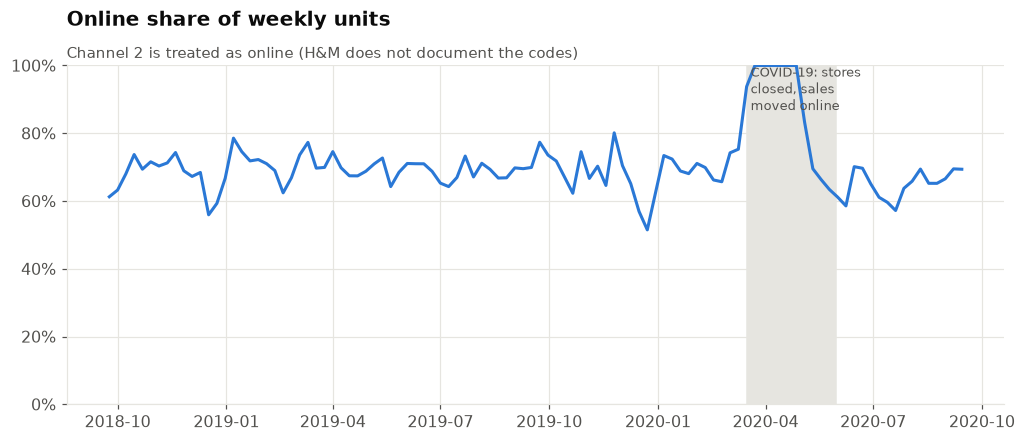

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(online.week_start, online.online_unit_share, color=charts.ACCENT)
shade_covid(ax)
charts.pct_axis(ax, "y")
ax.set_ylim(0, 1)
ax.set_title("Online share of weekly units")
charts.subtitle(ax, "Channel 2 is treated as online (H&M does not document the codes)")
charts.save(fig, "03_online_share")
plt.show()

## 2. Seasonality by garment group (Y1)

Index 1.0 = a typical month for that group. Planners use this shape to time buys and
markdowns.

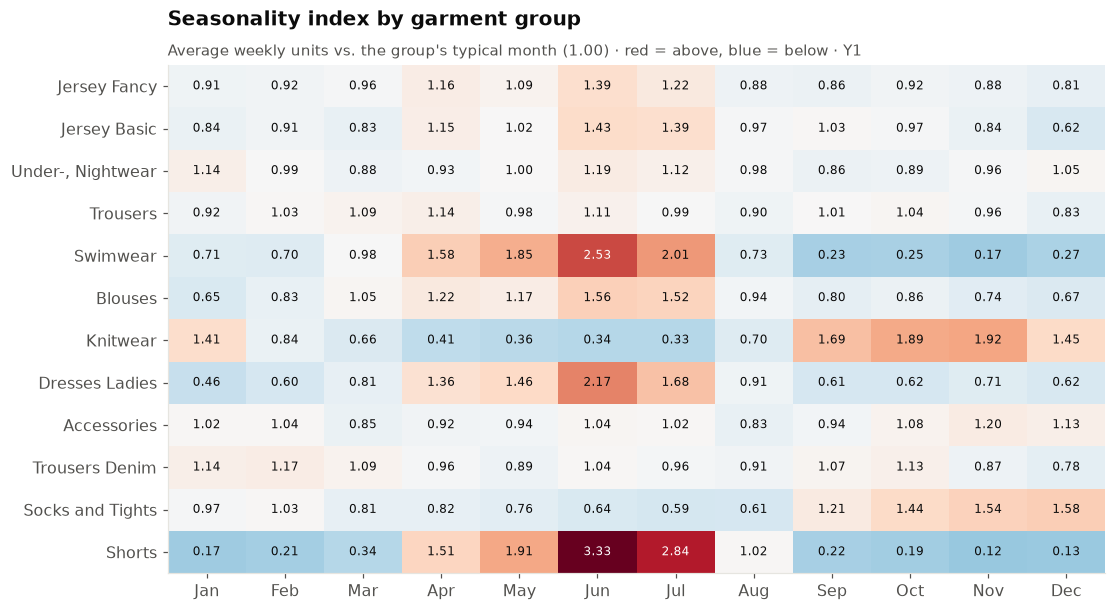

In [5]:
season = hm.q("monthly_seasonality_by_garment_group")
volume = hm.q("performance_by_garment_group").nlargest(12, "units").garment_group_name
grid = (season[season.garment_group_name.isin(volume)]
        .pivot_table(index="garment_group_name", columns="month_no", values="seasonality_index")
        .reindex(volume))
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(11, 6))
lim = np.nanmax(np.abs(grid.values - 1))
ax.imshow(grid.values - 1, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
ax.set_xticks(range(12), [months[m - 1] for m in grid.columns])
ax.set_yticks(range(grid.shape[0]), grid.index)
ax.grid(False)
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        value = grid.values[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(value - 1) > lim * 0.6 else charts.TEXT)
ax.set_title("Seasonality index by garment group")
charts.subtitle(ax, "Average weekly units vs. the group's typical month (1.00) · red = above, blue = below · Y1")
charts.save(fig, "03_seasonality_heatmap")
plt.show()

## 3. What gained and lost share year over year?

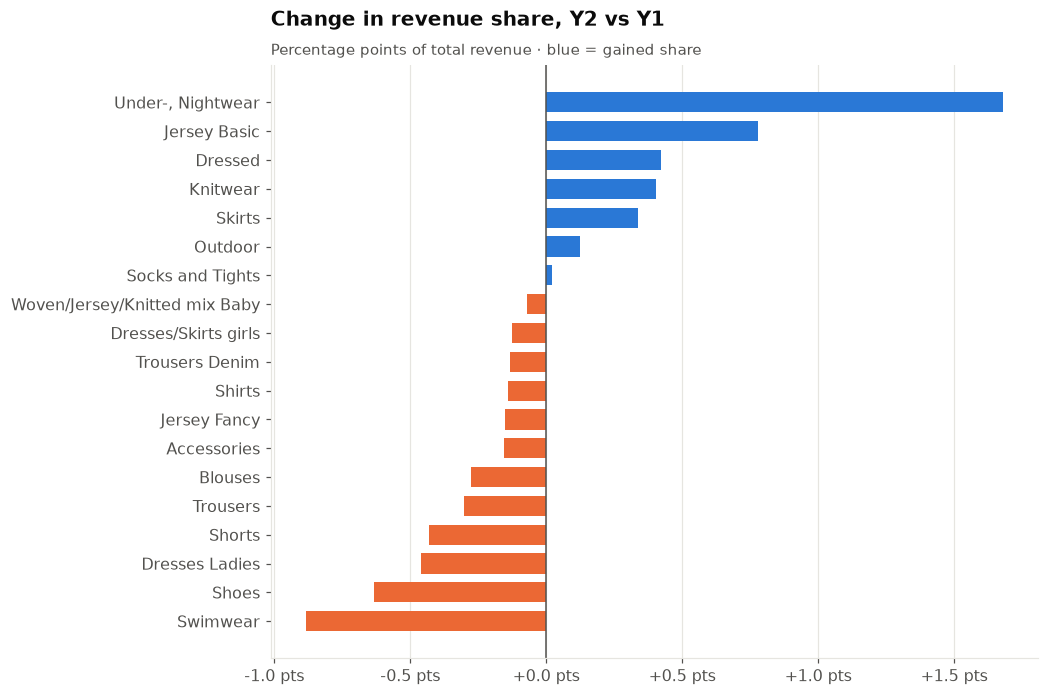

,garment_group_name,revenue_y1,revenue_y2,revenue_growth,share_y1,share_y2,share_change
0,"Under-, Nightwear","29,299.847","33,789.888",0.153,0.066,0.083,0.017
1,Jersey Basic,"24,565.189","25,763.847",0.049,0.055,0.063,0.008
2,Dressed,"10,890.487","11,741.959",0.078,0.025,0.029,0.004
3,Knitwear,"38,809.102","37,339.850",-0.038,0.088,0.092,0.004
4,Skirts,"10,382.216","10,919.481",0.052,0.023,0.027,0.003
5,Outdoor,"25,440.803","23,900.130",-0.061,0.057,0.059,0.001
6,Socks and Tights,"4,493.887","4,222.063",-0.060,0.010,0.010,0.000
7,Woven/Jersey/Knitted mix Baby,816.030,466.744,-0.428,0.002,0.001,-0.001
8,Dresses/Skirts girls,890.535,301.030,-0.662,0.002,0.001,-0.001
9,Trousers Denim,"27,047.284","24,330.395",-0.100,0.061,0.060,-0.001


In [6]:
def diverging(ax, labels, values, title, note):
    labels, values = list(labels)[::-1], np.asarray(values)[::-1]
    colors = [charts.POSITIVE if v >= 0 else charts.NEGATIVE for v in values]
    ax.barh(labels, values, color=colors, height=0.7)
    ax.axvline(0, color=charts.TEXT_SECONDARY, linewidth=1)
    ax.grid(axis="y", visible=False)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v * 100:+.1f} pts"))
    ax.set_title(title)
    charts.subtitle(ax, note)


yoy = hm.q("garment_group_yoy").dropna()
fig, ax = plt.subplots(figsize=(9, 7))
diverging(ax, yoy.garment_group_name, yoy.share_change,
          "Change in revenue share, Y2 vs Y1", "Percentage points of total revenue · blue = gained share")
charts.save(fig, "03_garment_group_share_change")
plt.show()
yoy

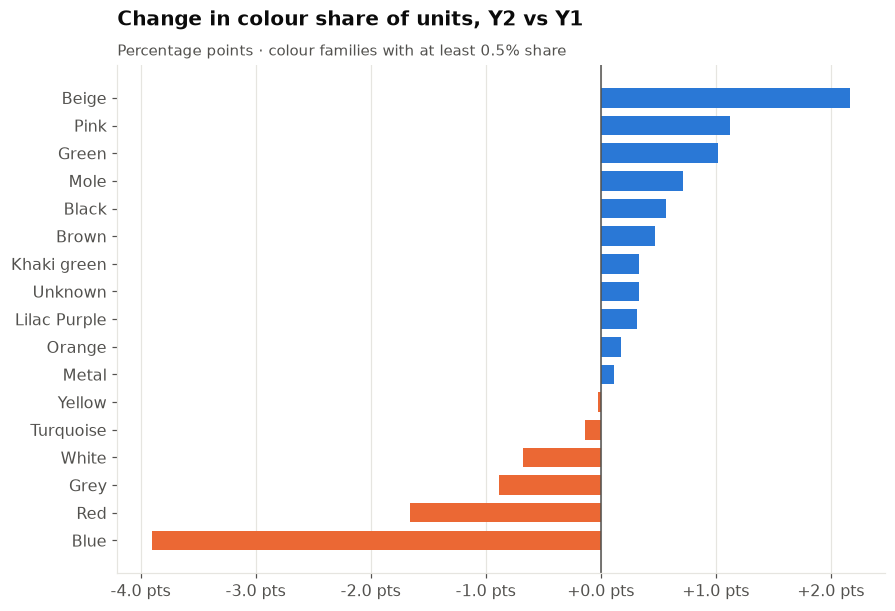

In [7]:
colour_yoy = hm.q("colour_share_yoy").dropna()
colour_yoy = colour_yoy[(colour_yoy.share_y1 >= 0.005) | (colour_yoy.share_y2 >= 0.005)]
fig, ax = plt.subplots(figsize=(9, 6))
diverging(ax, colour_yoy.perceived_colour_master_name, colour_yoy.share_change,
          "Change in colour share of units, Y2 vs Y1", "Percentage points · colour families with at least 0.5% share")
charts.save(fig, "03_colour_share_change")
plt.show()

## 4. Rising and falling product types

Latest 12 weeks vs. the same 12 weeks a year earlier. Using share of units (not raw
units) strips out swings in overall demand, so what remains is a change in what
customers choose.

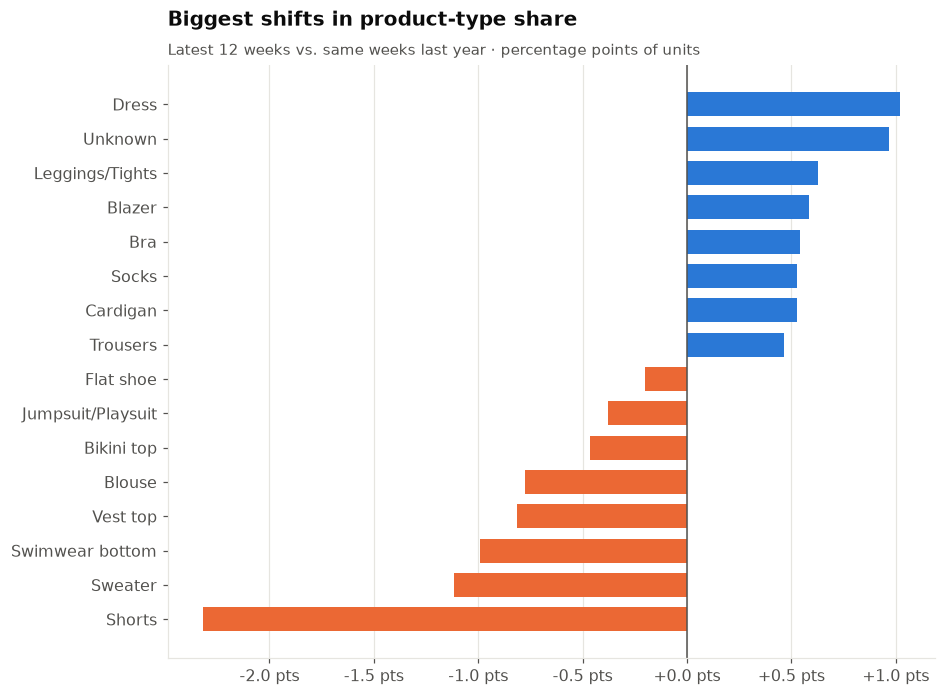

,product_type_name,product_group_name,units_recent,units_prior_year,share_recent,share_prior_year,share_change
0,Dress,Garment Full body,"405,216.000","412,874.000",0.118,0.108,0.010
1,Unknown,Unknown,"37,837.000","5,084.000",0.011,0.001,0.010
2,Leggings/Tights,Garment Lower body,"84,746.000","70,453.000",0.025,0.018,0.006
3,Blazer,Garment Upper body,"59,333.000","43,855.000",0.017,0.011,0.006
4,Bra,Underwear,"154,302.000","151,274.000",0.045,0.039,0.005
5,Socks,Socks & Tights,"57,682.000","44,217.000",0.017,0.012,0.005
6,Cardigan,Garment Upper body,"52,877.000","38,869.000",0.015,0.010,0.005
7,Trousers,Garment Lower body,"428,693.000","460,316.000",0.125,0.120,0.005
38,Flat shoe,Shoes,"3,048.000","11,151.000",0.001,0.003,-0.002
39,Jumpsuit/Playsuit,Garment Full body,"22,884.000","39,959.000",0.007,0.010,-0.004


In [8]:
momentum = hm.q("product_type_momentum")
movers = pd.concat([momentum.head(8), momentum.tail(8)])
fig, ax = plt.subplots(figsize=(9, 7))
diverging(ax, movers.product_type_name, movers.share_change,
          "Biggest shifts in product-type share", "Latest 12 weeks vs. same weeks last year · percentage points of units")
charts.save(fig, "03_product_type_momentum")
plt.show()
movers

## 5. Forecasting next quarter's weekly demand

For the three largest product groups, the last 12 weeks are held out and forecast four
ways, each only using data from before the held-out period:

| Method | Idea |
|---|---|
| Seasonal naive | Same week last year |
| Seasonal naive × recent trend | Same week last year, scaled by how the latest 8 weeks compare with a year earlier |
| Recent 8-week average | Flat line at the recent level |
| Seasonal regression | Linear regression on log units with a trend, yearly seasonal curves and a flag for the COVID-19 store-closure period |

Accuracy is measured with **WAPE** (total absolute error ÷ total actual units), the
standard retail metric; lower is better. Averages across groups can hide the fact
that the best method differs by product group, so both leading methods are shown
group by group.

In [9]:
series_df = hm.q("weekly_units_by_product_group")
series_df["week_start"] = pd.to_datetime(series_df.week_start)
top_groups = series_df.groupby("product_group_name").units.sum().nlargest(3).index

results, all_preds = [], {}
for group in top_groups:
    s = series_df[series_df.product_group_name == group].set_index("week_start").units
    preds, scores = forecast.compare_forecasts(s, horizon=12, disruption=(COVID_START, COVID_END))
    all_preds[group] = (s, preds)
    results.append(scores.rename(columns={"WAPE": group}))

wape_table = pd.concat(results, axis=1)
wape_table["Average"] = wape_table.mean(axis=1)
wape_table = wape_table.sort_values("Average")
for group in top_groups:
    print(f"{group}: best = {wape_table[group].idxmin()} ({wape_table[group].min():.1%} WAPE)")
wape_table.style.format("{:.1%}")

Garment Upper body: best = Recent 8-week average (13.0% WAPE)
Garment Lower body: best = Seasonal regression (13.8% WAPE)
Garment Full body: best = Seasonal naive x recent trend (20.9% WAPE)


,Garment Upper body,Garment Lower body,Garment Full body,Average
Seasonal naive x recent trend,17.0%,17.4%,20.9%,18.4%
Seasonal regression,14.1%,13.8%,27.6%,18.5%
Seasonal naive,22.6%,22.2%,21.1%,22.0%
Recent 8-week average,13.0%,30.8%,57.1%,33.6%


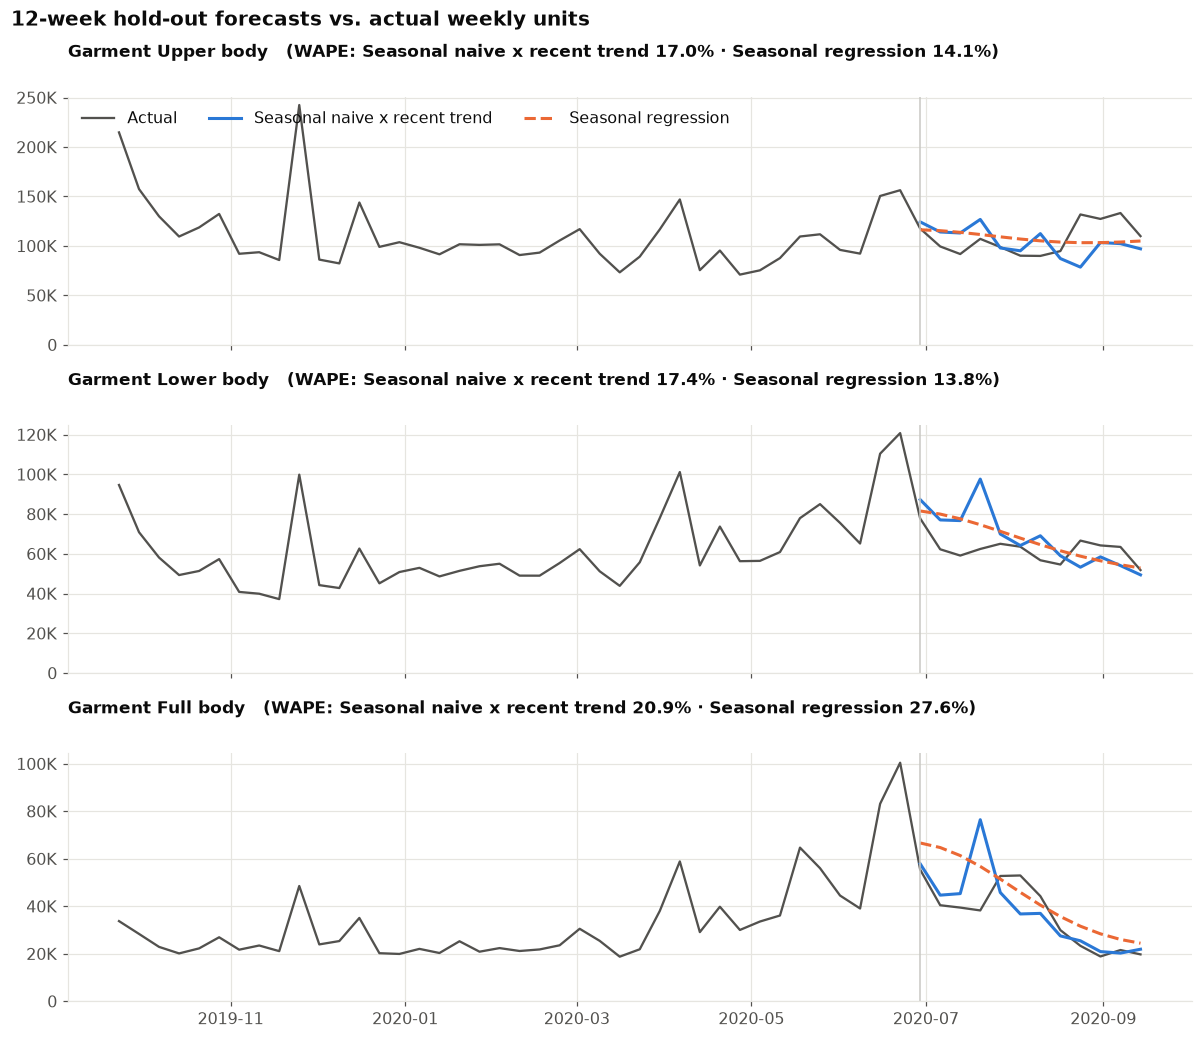

In [10]:
# The two methods with the lowest average WAPE, compared group by group
leaders = list(wape_table.index[:2])
leader_colors = dict(zip(leaders, [charts.ACCENT, charts.SERIES[1]]))

fig, axes = plt.subplots(len(top_groups), 1, figsize=(11, 3.2 * len(top_groups)), sharex=True)
for ax, group in zip(np.atleast_1d(axes), top_groups):
    s, preds = all_preds[group]
    history = s[s.index >= preds.index[0] - pd.Timedelta(weeks=40)]
    ax.plot(history.index, history.values, color=charts.TEXT_SECONDARY, linewidth=1.5, label="Actual")
    for method in leaders:
        ax.plot(preds.index, preds[method], color=leader_colors[method],
                linestyle="-" if method == leaders[0] else "--", label=method)
    ax.axvline(preds.index[0], color=charts.MUTED, linewidth=1)
    ax.set_ylim(0, None)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v / 1e3:,.0f}K" if v else "0"))
    scores = " · ".join(f"{m} {wape_table.loc[m, group]:.1%}" for m in leaders)
    ax.set_title(f"{group}   (WAPE: {scores})", fontsize=11)
axes[0].legend(loc="upper left", ncols=3)
fig.suptitle("12-week hold-out forecasts vs. actual weekly units", x=0.01, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
charts.save(fig, "03_forecast_holdout")
plt.show()

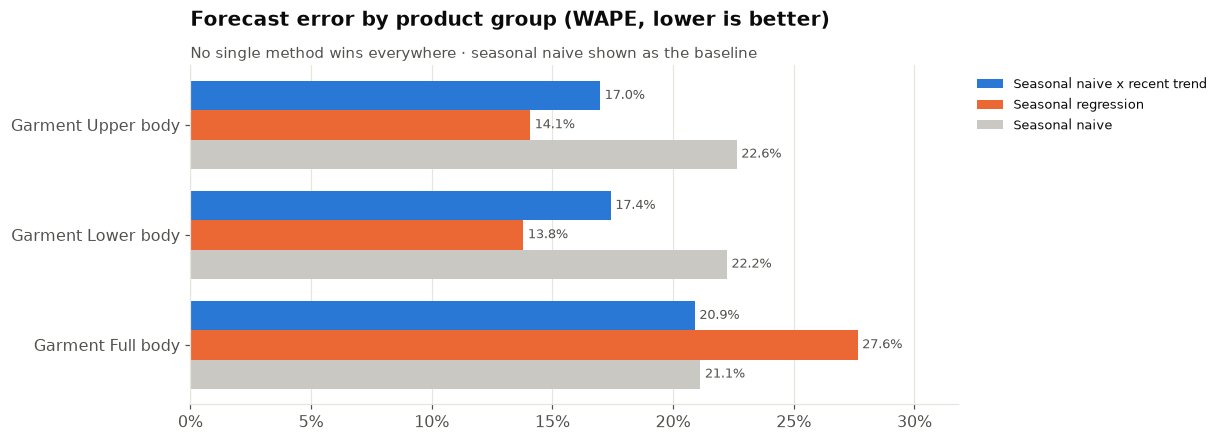

In [11]:
compare = wape_table.loc[leaders + ["Seasonal naive"], list(top_groups)]
fig, ax = plt.subplots(figsize=(9, 4))
bar_h = 0.8 / len(compare)
y = np.arange(len(top_groups))
for i, (method, color) in enumerate(zip(compare.index, [charts.ACCENT, charts.SERIES[1], charts.MUTED])):
    bars = ax.barh(y + i * bar_h, compare.loc[method], height=bar_h, color=color, label=method)
    ax.bar_label(bars, labels=[f"{v:.1%}" for v in compare.loc[method]], padding=3,
                 fontsize=8.5, color=charts.TEXT_SECONDARY)
ax.set_yticks(y + bar_h * (len(compare) - 1) / 2, top_groups)
ax.invert_yaxis()
charts.pct_axis(ax, "x")
ax.set_xlim(0, compare.values.max() * 1.15)
ax.grid(axis="y", visible=False)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8.5)
ax.set_title("Forecast error by product group (WAPE, lower is better)")
charts.subtitle(ax, "No single method wins everywhere · seasonal naive shown as the baseline")
charts.save(fig, "03_forecast_wape_by_group")
plt.show()

## Findings

- **Seasonality:** summer categories swing hardest. June demand runs at 3.3× a typical
  month for Shorts and 2.5× for Swimwear, falling to around 0.2× in autumn. Knitwear
  mirrors this, peaking at 1.9× in October–November. Basics such as Trousers and
  Under-/Nightwear stay within about ±20% all year, so they suit steadier replenishment.
- **Share shifts:** Year over year, Under-/Nightwear gained the most revenue share
  (+1.7 pts) while Swimwear lost the most (−0.9 pts). Beige gained 2.2 pts of unit share
  while Blue fell 3.9 pts, highlighting meaningful shifts in both category and colour
  mix between the two periods.
- **Channel shift:** online share of units rose from 69% in Y1 to 72% in Y2. During the
  store closures (16 Mar – 31 May 2020), store units fell 65% versus the same weeks of
  2019 and online units rose 7%, so total units fell 15%. Online absorbed much of the
  store decline but did not fully replace it.
- **Forecasting:** on a 12-week hold-out, seasonal regression is most accurate for Upper
  body (14.1% WAPE) and Lower body (13.8%), while seasonal naive × recent trend is best
  for Full body (20.9% vs. 27.6%). Their averages across groups are almost identical
  (18.4% vs. 18.5%), which hides the difference; a planner should back-test and choose a
  method per product group rather than use one method everywhere. For Full body the
  regression does worse than even the plain seasonal naive baseline (21.1%).